In [ ]:
import pandas as pd
import numpy

In [ ]:
import requests
import pandas as pd

api_key = '021ec3f59ed55d65d97105909ebe8fc5776802ad'
url = "https://api.tiingo.com/tiingo/daily/GE/prices?startDate=2015-01-01&endDate=2020-12-31"
headers = {
    'Content-Type': 'application/json',
    'Authorization': f'Token {api_key}'
}

response = requests.get(url, headers=headers)
data = response.json()
df = pd.DataFrame(data)
df.to_csv('GE.csv', index=False)


In [ ]:
df.head()

,date,close,high,low,open,volume,adjClose,adjHigh,adjLow,adjOpen,adjVolume,divCash,splitFactor
0,2015-01-02T00:00:00.000Z,25.06,25.46,24.87,25.34,40919008,103.034210,104.678810,102.253025,104.185430,8533533,0.0,1.0
1,2015-01-05T00:00:00.000Z,24.60,25.01,24.52,25.01,42033195,101.142920,102.828635,100.814000,102.828635,8765893,0.0,1.0
2,2015-01-06T00:00:00.000Z,24.07,24.57,23.93,24.46,63740067,98.963824,101.019575,98.388214,100.567310,13292794,0.0,1.0
3,2015-01-07T00:00:00.000Z,24.08,24.39,23.98,24.21,43638485,99.004939,100.279505,98.593789,99.539434,9100671,0.0,1.0
4,2015-01-08T00:00:00.000Z,24.37,24.38,24.13,24.32,43197484,100.197274,100.238389,99.210514,99.991699,9008702,0.0,1.0


In [ ]:
df.tail()

,date,close,high,low,open,volume,adjClose,adjHigh,adjLow,adjOpen,adjVolume,divCash,splitFactor
1506,2020-12-24T00:00:00.000Z,10.65,10.850,10.62,10.85,30049655,52.078686,53.056690,51.931986,53.056690,6029061,0.0,1.0
1507,2020-12-28T00:00:00.000Z,10.64,10.780,10.58,10.70,53565105,52.029786,52.714389,51.736385,52.323187,10747121,0.0,1.0
1508,2020-12-29T00:00:00.000Z,10.56,10.770,10.54,10.66,53035919,51.638585,52.665489,51.540785,52.127587,10640947,0.0,1.0
1509,2020-12-30T00:00:00.000Z,10.71,10.845,10.55,10.58,50621004,52.372088,53.032240,51.589685,51.736385,10156427,0.0,1.0
1510,2020-12-31T00:00:00.000Z,10.80,10.830,10.58,10.65,47702334,52.812189,52.958890,51.736385,52.078686,9570835,0.0,1.0


In [ ]:
df1=df.reset_index()['close']
df1

0       25.06
1       24.60
2       24.07
3       24.08
4       24.37
        ...  
1506    10.65
1507    10.64
1508    10.56
1509    10.71
1510    10.80
Name: close, Length: 1511, dtype: float64

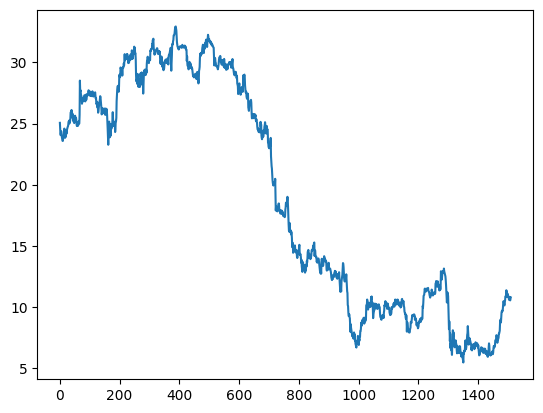

In [ ]:
import matplotlib.pyplot as plt
plt.plot(df1)

In [ ]:
import numpy as np

In [ ]:
from sklearn.preprocessing import MinMaxScaler
scaler=MinMaxScaler(feature_range=(0,1))
df1=scaler.fit_transform(np.array(df1).reshape(-1,1))

print(df1)

[[0.71319242]
 [0.69642857]
 [0.6771137 ]
 ...
 [0.18476676]
 [0.19023324]
 [0.19351312]]


In [ ]:
##splitting dataset into train and test split
training_size=int(len(df1)*0.65)
test_size=len(df1)-training_size
train_data,test_data=df1[0:training_size,:],df1[training_size:len(df1),:1]

In [ ]:
training_size,test_size

(982, 529)

In [ ]:
train_data

array([[0.71319242],
       [0.69642857],
       [0.6771137 ],
       [0.67747813],
       [0.68804665],
       [0.67565598],
       [0.67383382],
       [0.66946064],
       [0.66654519],
       [0.65925656],
       [0.65962099],
       [0.66909621],
       [0.67602041],
       [0.68476676],
       [0.69205539],
       [0.69606414],
       [0.68841108],
       [0.66873178],
       [0.67747813],
       [0.67055394],
       [0.68221574],
       [0.69169096],
       [0.68039359],
       [0.69278426],
       [0.69351312],
       [0.6978863 ],
       [0.70080175],
       [0.70262391],
       [0.70699708],
       [0.7164723 ],
       [0.71720117],
       [0.72011662],
       [0.71137026],
       [0.71865889],
       [0.71720117],
       [0.72521866],
       [0.7441691 ],
       [0.74344023],
       [0.74708455],
       [0.75145773],
       [0.74234694],
       [0.73505831],
       [0.74088921],
       [0.72631195],
       [0.73432945],
       [0.71720117],
       [0.71793003],
       [0.725

In [ ]:
# convert an array of values into a dataset matrix
def create_dataset(dataset, time_step=1):
	dataX, dataY = [], []
	for i in range(len(dataset)-time_step-1):
		a = dataset[i:(i+time_step), 0]   ###i=0, 0,1,2,3-----99   100
		dataX.append(a)
		dataY.append(dataset[i + time_step, 0])
	return numpy.array(dataX), numpy.array(dataY)

In [ ]:
# reshape into X=t,t+1,t+2,t+3 and Y=t+4
time_step = 100
X_train, y_train = create_dataset(train_data, time_step)
X_test, ytest = create_dataset(test_data, time_step)

In [ ]:
print(X_train.shape), print(y_train.shape)

(881, 100)
(881,)


(None, None)

In [ ]:
print(X_test.shape), print(ytest.shape)

(428, 100)
(428,)


(None, None)

In [ ]:
# reshape input to be [samples, time steps, features] which is required for LSTM
X_train =X_train.reshape(X_train.shape[0],X_train.shape[1] , 1)
X_test = X_test.reshape(X_test.shape[0],X_test.shape[1] , 1)

In [ ]:
### Create the Stacked LSTM model
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.layers import LSTM

In [ ]:
model=Sequential()
model.add(LSTM(50,return_sequences=True,input_shape=(100,1)))
model.add(LSTM(50,return_sequences=True))
model.add(LSTM(50))
model.add(Dense(1))
model.compile(loss='mean_squared_error',optimizer='adam')

C:\Users\surya\AppData\Roaming\Python\Python312\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [ ]:
model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_9 (LSTM)                   │ (None, 100, 50)        │        10,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_10 (LSTM)                  │ (None, 100, 50)        │        20,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_11 (LSTM)                  │ (None, 50)             │        20,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 50,851 (198.64 KB)

 Trainable params: 50,851 (198.64 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
model.fit(X_train,y_train,validation_data=(X_test,ytest),epochs=100,batch_size=64,verbose=1)

Epoch 1/100
14/14 ━━━━━━━━━━━━━━━━━━━━ 9s 202ms/step - loss: 0.2147 - val_loss: 0.0045
Epoch 2/100
14/14 ━━━━━━━━━━━━━━━━━━━━ 2s 131ms/step - loss: 0.0219 - val_loss: 0.0131
Epoch 3/100
14/14 ━━━━━━━━━━━━━━━━━━━━ 2s 111ms/step - loss: 0.0066 - val_loss: 0.0062
Epoch 4/100
14/14 ━━━━━━━━━━━━━━━━━━━━ 1s 106ms/step - loss: 0.0034 - val_loss: 0.0015
Epoch 5/100
14/14 ━━━━━━━━━━━━━━━━━━━━ 1s 101ms/step - loss: 0.0019 - val_loss: 0.0016
Epoch 6/100
14/14 ━━━━━━━━━━━━━━━━━━━━ 1s 101ms/step - loss: 0.0013 - val_loss: 0.0024
Epoch 7/100
14/14 ━━━━━━━━━━━━━━━━━━━━ 1s 94ms/step - loss: 0.0014 - val_loss: 0.0022
Epoch 8/100
14/14 ━━━━━━━━━━━━━━━━━━━━ 1s 107ms/step - loss: 0.0013 - val_loss: 0.0020
Epoch 9/100
14/14 ━━━━━━━━━━━━━━━━━━━━ 2s 128ms/step - loss: 0.0012 - val_loss: 0.0018
Epoch 10/100
14/14 ━━━━━━━━━━━━━━━━━━━━ 3s 135ms/step - loss: 0.0011 - val_loss: 0.0017
Epoch 11/100
14/14 ━━━━━━━━━━━━━━━━━━━━ 2s 133ms/step - loss: 0.0011 - val_loss: 0.0017
Epoch 12/100
14/14 ━━━━━━━━━━━━━━━━━━━━ 2s

In [ ]:
import tensorflow as tf
tf.__version__

'2.19.0'

In [ ]:
### Lets Do the prediction and check performance metrics
train_predict=model.predict(X_train)
test_predict=model.predict(X_test)

28/28 ━━━━━━━━━━━━━━━━━━━━ 2s 55ms/step
14/14 ━━━━━━━━━━━━━━━━━━━━ 1s 35ms/step


In [ ]:
##Transformback to original form
train_predict=scaler.inverse_transform(train_predict)
test_predict=scaler.inverse_transform(test_predict)

In [ ]:
### Calculate RMSE performance metrics
import math
from sklearn.metrics import mean_squared_error
math.sqrt(mean_squared_error(y_train,train_predict))

24.844597834066843

In [ ]:
### Test Data RMSE
math.sqrt(mean_squared_error(ytest,test_predict))

8.930856694837015

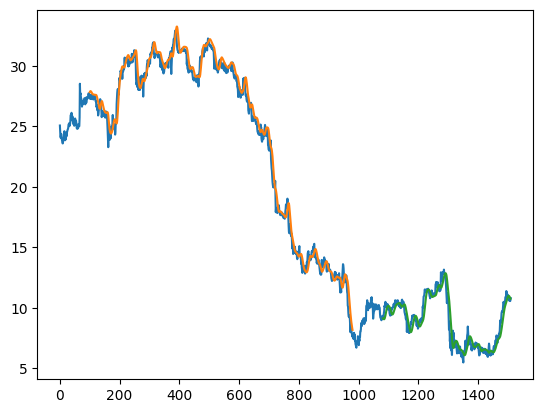

In [ ]:
### Plotting
# shift train predictions for plotting
look_back=100
trainPredictPlot = numpy.empty_like(df1)
trainPredictPlot[:, :] = np.nan
trainPredictPlot[look_back:len(train_predict)+look_back, :] = train_predict
# shift test predictions for plotting
testPredictPlot = numpy.empty_like(df1)
testPredictPlot[:, :] = numpy.nan
testPredictPlot[len(train_predict)+(look_back*2)+1:len(df1)-1, :] = test_predict
# plot baseline and predictions
plt.plot(scaler.inverse_transform(df1))
plt.plot(trainPredictPlot)
plt.plot(testPredictPlot)
plt.show()

In [ ]:
len(test_data)

529

In [ ]:
x_input=test_data[429:].reshape(1,-1)
x_input.shape

(1, 100)

In [ ]:
temp_input=list(x_input)
temp_input=temp_input[0].tolist()
temp_input

[0.04518950437317787,
 0.04482507288629736,
 0.040451895043731756,
 0.04263848396501457,
 0.0357142857142857,
 0.034620991253644345,
 0.03243440233236153,
 0.028425655976676373,
 0.029883381924198232,
 0.041545189504373164,
 0.040087463556851305,
 0.036078717201166205,
 0.036078717201166205,
 0.04081632653061226,
 0.03097667638483964,
 0.02551020408163268,
 0.034620991253644345,
 0.03024781341107874,
 0.03389212827988339,
 0.023688046647230315,
 0.024416909620991273,
 0.01858600583090378,
 0.01676384839650147,
 0.024052478134110794,
 0.022230320699708456,
 0.04591836734693877,
 0.05685131195335277,
 0.050655976676384856,
 0.03134110787172012,
 0.027696793002915443,
 0.022594752186588934,
 0.02077259475218657,
 0.022594752186588934,
 0.025874635568513132,
 0.022959183673469385,
 0.02696793002915454,
 0.027332361516034992,
 0.03279883381924198,
 0.03352769679300294,
 0.024781341107871724,
 0.029883381924198232,
 0.04227405247813412,
 0.04919825072886297,
 0.04883381924198252,
 0.04482507

In [ ]:
# demonstrate prediction for next 10 days
from numpy import array

lst_output=[]
n_steps=100
i=0
while(i<30):

    if(len(temp_input)>100):
        #print(temp_input)
        x_input=np.array(temp_input[1:])
        print("{} day input {}".format(i,x_input))
        x_input=x_input.reshape(1,-1)
        x_input = x_input.reshape((1, n_steps, 1))
        #print(x_input)
        yhat = model.predict(x_input, verbose=0)
        print("{} day output {}".format(i,yhat))
        temp_input.extend(yhat[0].tolist())
        temp_input=temp_input[1:]
        #print(temp_input)
        lst_output.extend(yhat.tolist())
        i=i+1
    else:
        x_input = x_input.reshape((1, n_steps,1))
        yhat = model.predict(x_input, verbose=0)
        print(yhat[0])
        temp_input.extend(yhat[0].tolist())
        print(len(temp_input))
        lst_output.extend(yhat.tolist())
        i=i+1


print(lst_output)

[0.18819538]
101
1 day input [0.04482507 0.0404519  0.04263848 0.03571429 0.03462099 0.0324344
 0.02842566 0.02988338 0.04154519 0.04008746 0.03607872 0.03607872
 0.04081633 0.03097668 0.0255102  0.03462099 0.03024781 0.03389213
 0.02368805 0.02441691 0.01858601 0.01676385 0.02405248 0.02223032
 0.04591837 0.05685131 0.05065598 0.03134111 0.02769679 0.02259475
 0.02077259 0.02259475 0.02587464 0.02295918 0.02696793 0.02733236
 0.03279883 0.0335277  0.02478134 0.02988338 0.04227405 0.04919825
 0.04883382 0.04482507 0.04846939 0.05029155 0.06559767 0.06559767
 0.06741983 0.06669096 0.08126822 0.07798834 0.06887755 0.05867347
 0.07033528 0.06851312 0.07033528 0.07397959 0.08600583 0.08600583
 0.09110787 0.09475219 0.11771137 0.12718659 0.12390671 0.1191691
 0.13702624 0.14868805 0.15269679 0.15451895 0.15196793 0.15561224
 0.16690962 0.18075802 0.18258017 0.17893586 0.17091837 0.16982507
 0.18002915 0.18622449 0.19642857 0.19569971 0.19934402 0.21501458
 0.21246356 0.20663265 0.19460641 0

In [ ]:
day_new=np.arange(1,101)
day_pred=np.arange(101,131)

In [ ]:
import matplotlib.pyplot as plt

In [ ]:
len(df1)

1511

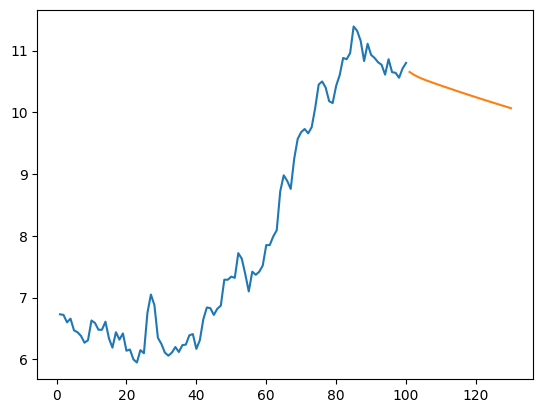

In [ ]:
plt.plot(day_new,scaler.inverse_transform(df1[1411:]))
plt.plot(day_pred,scaler.inverse_transform(lst_output))

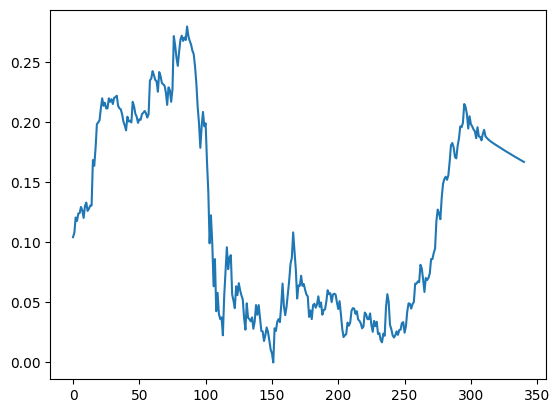

In [ ]:
df3=df1.tolist()
df3.extend(lst_output)
plt.plot(df3[1200:])

In [ ]:
df3=scaler.inverse_transform(df3).tolist()

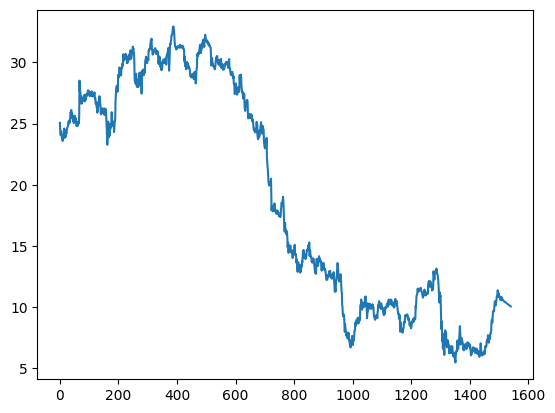

In [ ]:
plt.plot(df3)